In [ ]:
import pandas as pd
import requests
from google.colab import drive

# 1. 구글 드라이브 마운트 (연결)
# 코드를 처음 실행하면 구글 계정 권한 허용 창이 뜹니다. 허용해 주세요!
drive.mount('/content/drive')

# ==============================================================
# 🚨 팀원들이 각자 데이터에 맞게 수정해야 할 [세팅값] 구역 🚨
# ==============================================================

# 1. 카카오 REST API 키 (따옴표 안에 발급받은 키 입력)
KAKAO_API_KEY = "a74e16d4b116fdd2c8afc6ffb3310250"

# 2. 구글 드라이브에 올려둔 원본 CSV 파일의 경로
# (코랩 왼쪽 '폴더' 아이콘 > drive > MyDrive 에서 파일 찾은 뒤 우클릭 -> '경로 복사')
FILE_PATH = '/content/drive/MyDrive/영천의미학/지하수 이용관정.csv'

# 3. 주소가 들어있는 컬럼(기둥)의 정확한 이름
# (팀원마다 '도로명주소', '소재지지번주소' 등으로 다를 수 있으니 여기만 바꾸면 됨!)
ADDRESS_COLUMN = '주소'

# 4. 변환이 끝나고 저장될 새로운 파일의 이름과 경로
SAVE_FILE_NAME = '/content/drive/MyDrive/영천의미학/영천시_지하수_생활용_좌표완료.csv'

# ==============================================================

# 2. 카카오 로컬 API 지오코딩 함수
def get_lat_lng(address):
    url = f"https://dapi.kakao.com/v2/local/search/address.json?query={address}"
    headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}

    try:
        response = requests.get(url, headers=headers).json()
        # 검색 결과가 존재하면 좌표 리턴
        if response.get('documents'):
            lat = response['documents'][0]['y'] # 위도
            lng = response['documents'][0]['x'] # 경도
            return float(lat), float(lng)
        else:
            return None, None
    except Exception as e:
        return None, None


# 3. 만능 데이터 불러오기 및 필터링 (엑셀 위장 포맷, 모든 인코딩 대응)
print("데이터를 불러오는 중... (파일 형태를 분석합니다)")

def load_korean_data(file_path):
    # 1순위: 혹시 파일 내용물이 진짜 엑셀(.xlsx)인지 먼저 찔러보기
    try:
        temp_df = pd.read_excel(file_path)
        print("🎉 빙고! 이름만 CSV고 사실은 엑셀 파일이었습니다. 정상적으로 불러왔습니다!")
        return temp_df
    except:
        pass

    # 2순위: 진짜 CSV가 맞다면, 가능한 모든 한국어 인코딩을 순서대로 때려 넣기
    encodings = ['utf-8', 'cp949', 'euc-kr', 'utf-8-sig', 'iso-8859-1']
    for enc in encodings:
        try:
            temp_df = pd.read_csv(file_path, encoding=enc)
            print(f"🎉 빙고! [{enc}] 인코딩으로 파일을 무사히 열었습니다!")
            return temp_df
        except UnicodeDecodeError:
            continue # 에러 나면 다음 인코딩으로 넘어감
        except Exception as e:
            print(f"다른 에러 발생: {e}")
            break

    print("🚨 모든 방법 실패! 파일을 구글 드라이브에서 열어서 구글 스프레드시트로 확인해 보세요.")
    return None

# 만능 함수 실행!
df = load_korean_data(FILE_PATH)

# 데이터가 무사히 열렸다면 B팀 미션(생활용 필터링) 진행
if df is not None:
    if '지하수용도' in df.columns:
        df = df[df['지하수용도'] == '생활용'].copy()
        print(f"👉 '생활용' 데이터 필터링 완료! 남은 분석 대상: {len(df)}개")
    else:
        print("⚠️ '지하수용도' 컬럼을 찾을 수 없습니다. 컬럼명들을 확인해 주세요:", df.columns.tolist())

# B팀 미션: '생활용' 지하수만 필터링 (필요 없는 팀원은 이 부분을 주석 처리하면 됨)
if '지하수용도' in df.columns:
    df = df[df['지하수용도'] == '생활용'].copy()
    print(f"👉 '생활용' 데이터 필터링 완료! 남은 분석 대상: {len(df)}개")

# 4. 주소를 좌표로 변환 적용 (핵심 엔진)
print(f"\n🚀 [{ADDRESS_COLUMN}] 컬럼의 주소들을 위경도로 변환합니다...")
print("(데이터가 많으면 1~2분 정도 걸릴 수 있으니 창을 닫지 마세요!)")

# apply 함수로 전체 주소 컬럼에 변환 함수를 씌우고, 결과를 '위도', '경도' 두 파트로 나눔
df['위도'], df['경도'] = zip(*df[ADDRESS_COLUMN].astype(str).apply(get_lat_lng))

# 5. 결과 확인 및 저장
missing_count = df['위도'].isnull().sum()
print(f"\n✅ 변환 완료! 총 {len(df)}개 중 좌표를 못 찾은 결측치(이상치): {missing_count}개")

# 엑셀에서 한글이 깨지지 않도록 'utf-8-sig' 인코딩으로 저장
df.to_csv(SAVE_FILE_NAME, index=False, encoding='utf-8-sig')
print(f"💾 파일이 구글 드라이브에 안전하게 저장되었습니다: {SAVE_FILE_NAME}")

# 변환된 데이터 상위 3개 미리보기
print("\n[변환된 데이터 미리보기]")
display(df[[ADDRESS_COLUMN, '위도', '경도']].head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터를 불러오는 중... (파일 형태를 분석합니다)
🎉 빙고! [utf-8] 인코딩으로 파일을 무사히 열었습니다!
👉 '생활용' 데이터 필터링 완료! 남은 분석 대상: 1242개
👉 '생활용' 데이터 필터링 완료! 남은 분석 대상: 1242개

🚀 [주소] 컬럼의 주소들을 위경도로 변환합니다...
(데이터가 많으면 1~2분 정도 걸릴 수 있으니 창을 닫지 마세요!)

✅ 변환 완료! 총 1242개 중 좌표를 못 찾은 결측치(이상치): 0개
💾 파일이 구글 드라이브에 안전하게 저장되었습니다: /content/drive/MyDrive/영천의미학/영천시_지하수_생활용_좌표완료.csv

[변환된 데이터 미리보기]


,주소,위도,경도
5,경상북도 영천시 청통면 치일리 230,35.991206,128.805235
7,경상북도 영천시 망정동 117,35.971830,128.949470
8,경상북도 영천시 신녕면 화남리 652,36.078270,128.761037


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping

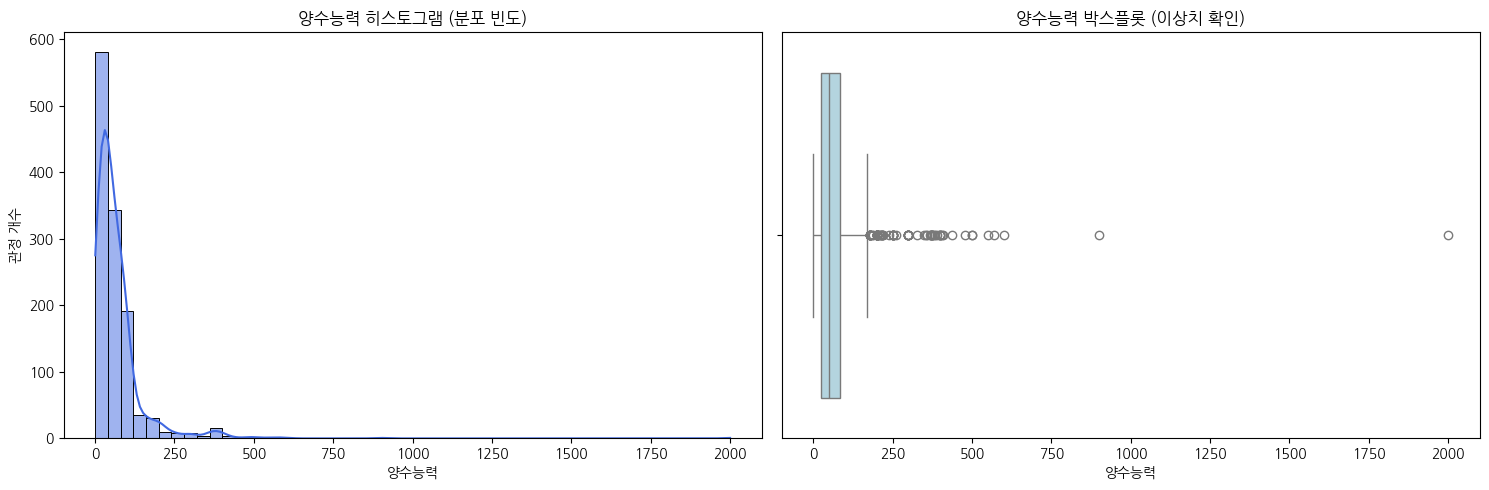

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
from google.colab import drive

# 1. 구글 드라이브 마운트 (연결)
# 코드를 처음 실행하면 구글 계정 권한 허용 창이 뜹니다. 허용해 주세요!
drive.mount('/content/drive')

# 한글 폰트 깨짐 방지 (코랩 환경용)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
plt.rc('font', family='NanumGothic')

# 1. 좌표 변환이 완료된 데이터 불러오기
FILE_PATH = '/content/drive/MyDrive/영천의미학/영천시_지하수_생활용_좌표완료.csv'
df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')

# ==============================================================
# 🚨 팀원들이 확인해야 할 [세팅값] 구역 🚨
# ==============================================================
# 양수능력이 적힌 정확한 컬럼명을 확인 후 아래 변수에 넣어주세요.
# (예: '양수능력(톤/일)', '일양수량', '양수능력' 등)
print("현재 데이터의 컬럼 목록:", df.columns.tolist())

# 👇 실제 데이터에 맞게 이름을 수정하세요!
CAPACITY_COLUMN = '양수능력(㎥/일)'
# ==============================================================

# 2. 결측치 및 이상치 처리 (숫자형으로 변환)
# 혹시 문자열(예: '10톤')이 섞여 있을 수 있으니 숫자만 추출
df[CAPACITY_COLUMN] = pd.to_numeric(df[CAPACITY_COLUMN].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')

# 결측치(NaN) 제외하고 분석할 임시 데이터프레임 생성
df_valid = df.dropna(subset=[CAPACITY_COLUMN])

print(f"\n✅ 전체 데이터 {len(df)}개 중 양수능력 수치가 있는 데이터: {len(df_valid)}개")

# 3. 주요 통계량 및 백분위수(Percentile) 확인
print("\n[양수능력 주요 통계량 및 백분위수 (톤/일)]")
quantiles = [0.25, 0.5, 0.75, 0.8, 0.9, 0.95]
stats = df_valid[CAPACITY_COLUMN].describe(percentiles=quantiles)
print(stats)

# 4. 데이터 분포 시각화 (히스토그램 & 박스플롯)
plt.figure(figsize=(15, 5))

# 히스토그램 (어느 구간에 데이터가 가장 많이 몰려있는지 파악)
plt.subplot(1, 2, 1)
sns.histplot(df_valid[CAPACITY_COLUMN], bins=50, kde=True, color='royalblue')
plt.title('양수능력 히스토그램 (분포 빈도)')
plt.xlabel('양수능력')
plt.ylabel('관정 개수')

# 박스플롯 (극단적인 대형 관정(이상치)이 얼마나 있는지 파악)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_valid[CAPACITY_COLUMN], color='lightblue')
plt.title('양수능력 박스플롯 (이상치 확인)')
plt.xlabel('양수능력')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. 좌표 변환이 완료된 데이터 불러오기
FILE_PATH = '/content/drive/MyDrive/영천의미학/영천시_지하수_생활용_좌표완료.csv'
df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')

# 2. 양수능력 컬럼 지정 및 숫자형 변환
CAPACITY_COLUMN = '양수능력(㎥/일)'
df[CAPACITY_COLUMN] = pd.to_numeric(df[CAPACITY_COLUMN].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')

# 결측치 제외
df_valid = df.dropna(subset=[CAPACITY_COLUMN])

print(f"✅ 분석 대상 관정 수: {len(df_valid)}개 (결측치 제외)\n")

# 3. 촘촘한 백분위수(Percentile) 계산
quantiles = [0.1, 0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99, 1.0]
stats = df_valid[CAPACITY_COLUMN].quantile(quantiles)

print("-" * 40)
print("📊 [양수능력 수치 분포 결과 (복사해서 붙여넣어 주세요!)]")
print("-" * 40)
print(f"최소값 (0%)   : {df_valid[CAPACITY_COLUMN].min()} 톤/일")
for q in quantiles:
    print(f"하위 {int(q*100):>2}% 지점 : {stats[q]:.2f} 톤/일")
print("-" * 40)

✅ 분석 대상 관정 수: 1236개 (결측치 제외)

----------------------------------------
📊 [양수능력 수치 분포 결과 (복사해서 붙여넣어 주세요!)]
----------------------------------------
최소값 (0%)   : 1.0 톤/일
하위 10% 지점 : 10.00 톤/일
하위 25% 지점 : 25.00 톤/일
하위 50% 지점 : 50.00 톤/일
하위 75% 지점 : 85.00 톤/일
하위 80% 지점 : 90.00 톤/일
하위 85% 지점 : 100.00 톤/일
하위 90% 지점 : 120.00 톤/일
하위 95% 지점 : 200.00 톤/일
하위 99% 지점 : 400.00 톤/일
하위 100% 지점 : 2000.00 톤/일
----------------------------------------


In [ ]:
# ==============================================================
# 🚨 팀 회의로 결정된 커트라인 및 저장 경로 설정 구역 🚨
# ==============================================================
# 법적(지하수법 시행령), 통계적 근거를 바탕으로 산출된 개별 가구 소규모 관정 기준치
THRESHOLD = 30.0

# 요청하신 파일명으로 저장 경로 설정
FINAL_SAVE_FILE_NAME = '/content/drive/MyDrive/영천의미학/지하수_생활용_양수능력고려.csv'
# ==============================================================

# 1. 30톤 이하의 소규모 관정만 추출 (진짜 사각지대)
df_small_scale = df_valid[df_valid['양수능력(㎥/일)'] <= THRESHOLD].copy()

print(f"\n🚀 커트라인({THRESHOLD}톤/일) 이하 소규모 관정 추출 완료!")
print(f"👉 전체 관정: {len(df_valid)}개 -> 진짜 사각지대 타겟: {len(df_small_scale)}개")

# 2. 최종 결과물 저장
df_small_scale.to_csv(FINAL_SAVE_FILE_NAME, index=False, encoding='utf-8-sig')
print(f"💾 실질 취약 관정 데이터가 지정된 이름으로 안전하게 저장되었습니다.")
print(f"📂 저장 위치: {FINAL_SAVE_FILE_NAME}")

# 3. 최종 데이터 미리보기
display(df_small_scale.head(3))


🚀 커트라인(30.0톤/일) 이하 소규모 관정 추출 완료!
👉 전체 관정: 1236개 -> 진짜 사각지대 타겟: 544개
💾 실질 취약 관정 데이터가 지정된 이름으로 안전하게 저장되었습니다.
📂 저장 위치: /content/drive/MyDrive/영천의미학/지하수_생활용_양수능력고려.csv


,허가신고형태,주소,지하수용도,지하수세부용도,지하수음용여부,굴착심도(m),굴착직경(mm),설치심도(m),소요수량(㎥/일),취수계획량(㎥/일),양수능력(㎥/일),동력장치마력(HP),토출관 직경(mm),위도,경도
2,기타공,경상북도 영천시 신녕면 화남리 652,생활용,일반용,-,60.0,50,0,0,0,10.0,1.0,50,36.078270,128.761037
3,기타공,경상북도 영천시 신녕면 화남리 652,생활용,일반용,-,60.0,50,0,0,0,10.0,1.0,50,36.078270,128.761037
4,기타공,경상북도 영천시 금호읍 남성리 293,생활용,가정용,-,24.0,75,0,0,0,30.0,0.0,0,35.902883,128.873109


🔄 [1/3] SGIS 정밀 경계선 및 1km 격자판 세팅 중...
💧 [2/3] 정제된 소규모 지하수 데이터를 격자에 맵핑합니다...
✨ [3/3] 영천시 소규모 지하수 밀집도 지도 출력!


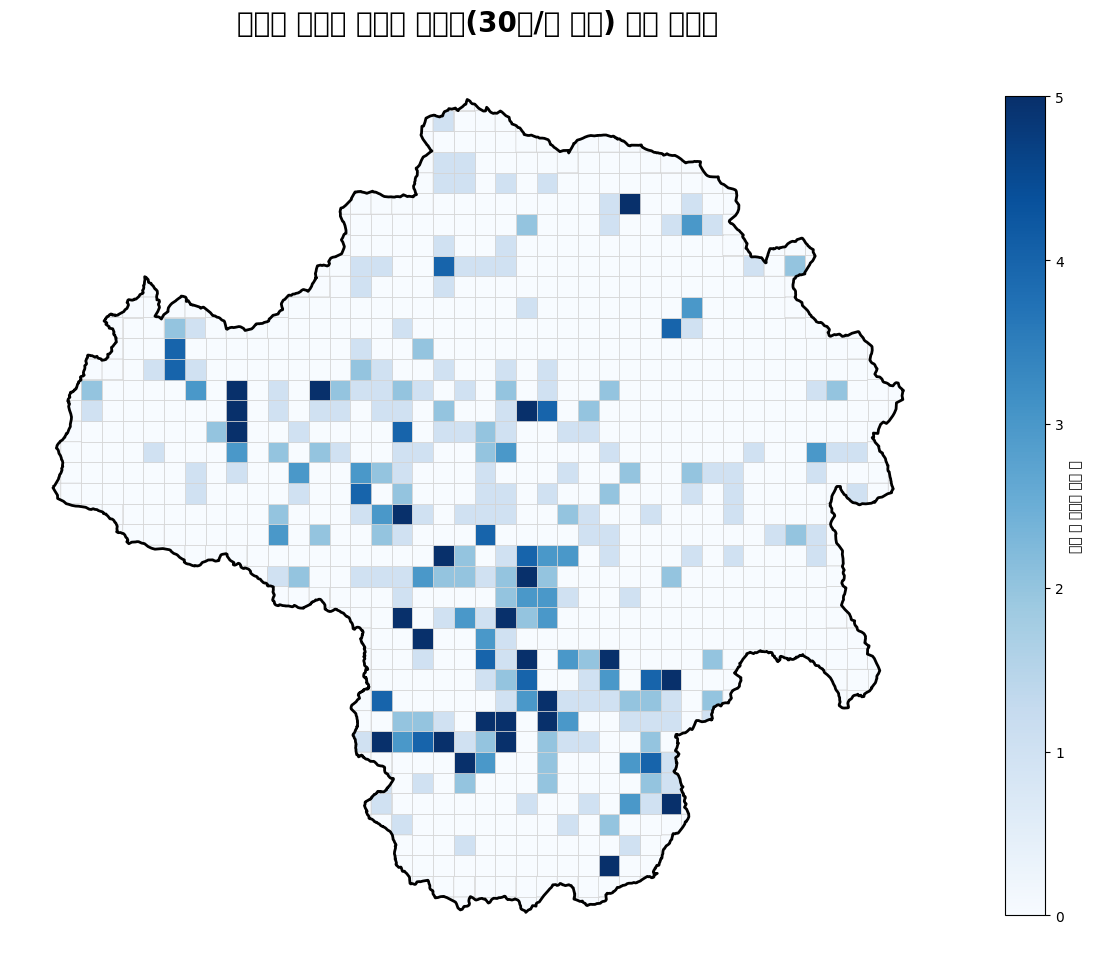

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings

# 경고창 무시
warnings.filterwarnings('ignore')

# 코랩 한글 폰트 설정 (깨짐 방지)
plt.rc('font', family='NanumBarunGothic')

# ==============================================================
# 🚨 [세팅값] 데이터 경로 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 1km 격자 및 SGIS 정밀 경계선 경로
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'

# 🌟 새롭게 생성한 30톤 이하 소규모 관정 데이터 경로로 변경!
WATER_PATH = BASE_DIR + '지하수_생활용_양수능력고려.csv'

# ==============================================================
print("🔄 [1/3] SGIS 정밀 경계선 및 1km 격자판 세팅 중...")
# ==============================================================
# 1. SGIS 정밀 경계선 불러오기
try:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')

sigungu_map = sigungu_map.to_crs(epsg=5179)
sigungu_map['SIGUNGU_NM'] = sigungu_map['SIGUNGU_NM'].astype(str).str.strip()
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'] == '영천시'].copy()

# 파일 자체가 영천시 단일 데이터인 경우 대비
if len(yeongcheon_border) == 0:
    yeongcheon_border = sigungu_map.copy()

# 2. 1km 격자판 불러오기 및 영천시 경계로 오려내기(Clip)
try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()

# ==============================================================
print("💧 [2/3] 정제된 소규모 지하수 데이터를 격자에 맵핑합니다...")
# ==============================================================
# 1. 지하수 공간 병합 (sjoin)
df_water = pd.read_csv(WATER_PATH).dropna(subset=['위도', '경도'])
gdf_water = gpd.GeoDataFrame(df_water, geometry=gpd.points_from_xy(df_water['경도'], df_water['위도']), crs="EPSG:4326").to_crs(epsg=5179)

joined_water = gpd.sjoin(gdf_water, yeongcheon_grid, how='inner', predicate='within')
water_counts = joined_water.groupby(grid_col).size().reset_index(name='water_wells')

# 2. 격자 지도에 카운트 값 결합 (관정이 없는 격자는 0 처리)
final_map = yeongcheon_grid.merge(water_counts, on=grid_col, how='left')
final_map['water_wells'] = final_map['water_wells'].fillna(0)

# 시각적 대비 강화를 위한 상위 % Capping
water_vmax = max(final_map['water_wells'].quantile(0.98), 5)

# ==============================================================
print("✨ [3/3] 영천시 소규모 지하수 밀집도 지도 출력!")
# ==============================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 격자 색상 칠하기 (값이 클수록 진한 파란색)
final_map.plot(column='water_wells', ax=ax, cmap='Blues', vmax=water_vmax,
               edgecolor='lightgray', linewidth=0.5, legend=True,
               legend_kwds={'label': "격자 내 소규모 관정 수", 'orientation': "vertical", 'shrink': 0.7})

# 영천시 외곽선 강조
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2)

ax.set_title("영천시 소규모 생활용 지하수(30톤/일 이하) 밀집 핫스팟", fontsize=20, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🗺️ [Phase 1] 1km 격자 지도를 불러옵니다...
✅ 지도 로드 완료! 총 7721개의 격자가 있습니다.
👉 지도의 격자코드(Key) 컬럼명은 [GRID_CD] 입니다.

📊 [Phase 2] 인구 및 가구 데이터를 불러와 지도에 결합합니다...
✅ 인구 데이터(201427줄), 가구 데이터(25669줄) 로드 완료!

🎉 [Phase 2 완료] 지도에 통계 데이터가 완벽하게 결합되었습니다!
결합된 데이터 상위 3줄 미리보기:


/tmp/ipykernel_19480/3973545071.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_map = merged_map.fillna(0)


,GRID_CD,geometry,2024_인구,마마0000_인구,in_age_004,0,2024_가구,마마0000_가구,ga_sd_001,13
0,留留0000,"POLYGON ((1100000 1700000, 1100000 1701000, 11...",0.0,0,0,0.0,0.0,0,0,0.0
1,留留0001,"POLYGON ((1100000 1701000, 1100000 1702000, 11...",0.0,0,0,0.0,0.0,0,0,0.0
2,留留0002,"POLYGON ((1100000 1702000, 1100000 1703000, 11...",0.0,0,0,0.0,0.0,0,0,0.0



💧 [Phase 3] 지하수 좌표 데이터를 불러와 지도에 얹습니다...
👉 좌표가 있는 지하수 관정: 1242개
✅ [Phase 3 완료] 격자별 지하수 관정 카운트가 끝났습니다!

✂️ [Phase 3.5] 영천시 경계선으로 도화지를 예쁘게 오려냅니다...
✅ 완벽하게 잘라냈습니다! 최종 영천시 1km 격자 개수: 1007개


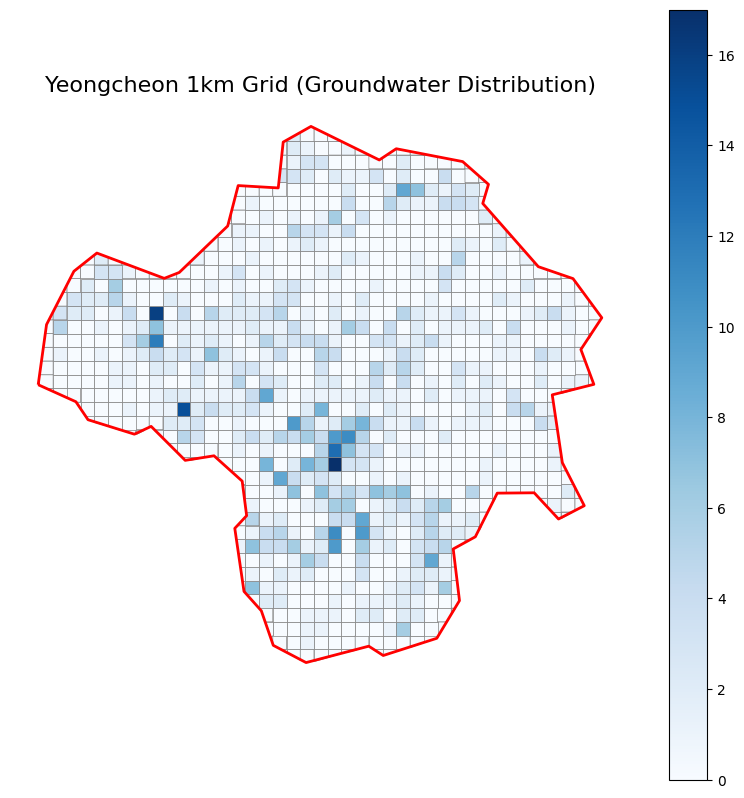

In [ ]:
# 0. 필수 라이브러리 설치 (코랩 환경용)
!pip install geopandas -q

import pandas as pd
import geopandas as gpd
from google.colab import drive
import matplotlib.pyplot as plt

# 구글 드라이브 마운트
drive.mount('/content/drive')

# ==============================================================
# 🚨 [세팅값] 파일 경로 설정 (캡처본 기반으로 작성 완료!)
# ==============================================================
# 기본 폴더 경로
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 1. 1km 격자 지도 파일 경로 (압축 푼 폴더 안의 .shp 파일)
# (만약 폴더 이름이 다르면 이 부분을 수정해 줘!)
SHP_PATH = BASE_DIR + '/_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'

# 2. 인구 및 가구 통계 CSV 파일 경로
POP_PATH = BASE_DIR + '2024년_인구_마마_1K.csv'
FAM_PATH = BASE_DIR + '2024년_가구_마마_1K.csv'

# ==============================================================
# Phase 1: 도화지 깔기 (Base Map Setup)
# ==============================================================
print("\n🗺️ [Phase 1] 1km 격자 지도를 불러옵니다...")

# SHP 파일 로드 (통계청 지도는 보통 euc-kr 인코딩)
try:
    grid_map = gpd.read_file(SHP_PATH, encoding='euc-kr')
    # 통계청 기준 좌표계(EPSG:5179) 강제 지정
    grid_map = grid_map.set_crs(epsg=5179, allow_override=True)
    print(f"✅ 지도 로드 완료! 총 {len(grid_map)}개의 격자가 있습니다.")
except Exception as e:
    print(f"❌ 지도 로드 실패. SHP 파일 경로를 다시 확인해 주세요: {e}")

# 지도 격자코드 컬럼명 확인 (나중에 병합할 때 필요)
# 통계청 격자지도는 보통 'GRID_ID', 'lbl', 'TOT_REG_CD' 중 하나를 씁니다.
grid_key = grid_map.columns[0] # 보통 첫 번째 컬럼이 ID
print(f"👉 지도의 격자코드(Key) 컬럼명은 [{grid_key}] 입니다.")

# ==============================================================
# Phase 2: 사회적 취약도 맵핑 (Attribute Join)
# ==============================================================
print("\n📊 [Phase 2] 인구 및 가구 데이터를 불러와 지도에 결합합니다...")

# 공공데이터 CSV를 안전하게 불러오는 함수 (인코딩 에러 방지)
def load_korean_csv(path):
    encodings = ['cp949', 'euc-kr', 'utf-8']
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except:
            continue
    return None

# 데이터 로드
df_pop = load_korean_csv(POP_PATH)
df_fam = load_korean_csv(FAM_PATH)

print(f"✅ 인구 데이터({len(df_pop)}줄), 가구 데이터({len(df_fam)}줄) 로드 완료!")

# CSV 파일의 격자코드 컬럼명 찾기 (보통 '격자코드' 또는 'TOT_REG_CD')
# 엑셀 파일은 B열(보통 인덱스 1)에 코드가 있습니다.
csv_key_pop = df_pop.columns[1]
csv_key_fam = df_fam.columns[1]

# 1. 지도 + 인구 데이터 결합 (Merge)
merged_map = grid_map.merge(df_pop, left_on=grid_key, right_on=csv_key_pop, how='left')

# 2. 결합된 지도 + 가구 데이터 결합 (Merge)
merged_map = merged_map.merge(df_fam, left_on=grid_key, right_on=csv_key_fam, how='left', suffixes=('_인구', '_가구'))

# 결측치(데이터가 없는 산속 격자 등) 0으로 채우기
merged_map = merged_map.fillna(0)

print(f"\n🎉 [Phase 2 완료] 지도에 통계 데이터가 완벽하게 결합되었습니다!")
print("결합된 데이터 상위 3줄 미리보기:")
display(merged_map.head(3))

import warnings
import requests
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ==============================================================
# 🚨 [세팅값] 지하수 좌표완료 파일 경로 (확인 필수)
# ==============================================================
WATER_PATH = BASE_DIR + '영천시_지하수_생활용_좌표완료.csv'

# ==============================================================
# Phase 3: 식수 고립도 맵핑 (지하수 점 찍고 개수 세기)
# ==============================================================
print("\n💧 [Phase 3] 지하수 좌표 데이터를 불러와 지도에 얹습니다...")

# 1. 지하수 데이터 로드 및 좌표 결측치 제거
df_water = load_korean_csv(WATER_PATH)
df_water_clean = df_water.dropna(subset=['위도', '경도']).copy()
print(f"👉 좌표가 있는 지하수 관정: {len(df_water_clean)}개")

# 2. 일반 텍스트 데이터를 공간 데이터(GeoDataFrame)로 변환 (EPSG:4326)
gdf_water = gpd.GeoDataFrame(
    df_water_clean,
    geometry=gpd.points_from_xy(df_water_clean['경도'], df_water_clean['위도']),
    crs="EPSG:4326"
)

# 3. 좌표계 통일 (위경도 4326 -> 미터법 5179)
gdf_water = gdf_water.to_crs(epsg=5179)

# 4. 공간 결합 (이 점들이 어떤 격자 안에 떨어지나 확인)
joined = gpd.sjoin(gdf_water, merged_map, how='inner', predicate='within')

# 5. 격자코드(GRID_CD)별로 지하수가 몇 개 있는지 세기
water_counts = joined.groupby('GRID_CD').size().reset_index(name='지하수관정수')

# 6. 세어둔 개수를 원래 지도에 결합 (드디어 final_map 탄생!)
final_map = merged_map.merge(water_counts, on='GRID_CD', how='left')
final_map['지하수관정수'] = final_map['지하수관정수'].fillna(0)

print("✅ [Phase 3 완료] 격자별 지하수 관정 카운트가 끝났습니다!")


# ==============================================================
# Phase 3.5: '쿠키 커터'로 영천시 모양 완벽하게 오려내기 (Clip)
# ==============================================================
print("\n✂️ [Phase 3.5] 영천시 경계선으로 도화지를 예쁘게 오려냅니다...")

# 1. 깃허브 오픈소스에서 시군구 경계 데이터 불러오기
url = "https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2013/json/skorea_municipalities_geo_simple.json"
korea_sig = gpd.read_file(url)

# 2. '영천시'만 추출 (쿠키 커터)
yeongcheon_border = korea_sig[korea_sig['name'] == '영천시'].copy()
yeongcheon_border = yeongcheon_border.to_crs(epsg=5179) # 좌표계 통일

# 3. 쿠키 커터로 지도 잘라내기!
perfect_yeongcheon_grid = gpd.clip(final_map, yeongcheon_border)
print(f"✅ 완벽하게 잘라냈습니다! 최종 영천시 1km 격자 개수: {len(perfect_yeongcheon_grid)}개")


# ==============================================================
# ✨ 최종 지도 시각화 (눈으로 확인하기)
# ==============================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 격자판 그리기 (지하수 많은 곳은 진한 파란색)
perfect_yeongcheon_grid.plot(column='지하수관정수', ax=ax, cmap='Blues', edgecolor='gray', linewidth=0.5, legend=True)

# 영천시 외곽선 덧그리기 (빨간색 선)
yeongcheon_border.boundary.plot(ax=ax, color='red', linewidth=2)

plt.title("Yeongcheon 1km Grid (Groundwater Distribution)", fontsize=16)
plt.axis('off')
plt.show()

In [ ]:
import pandas as pd

# ==============================================================
# 🚨 [세팅값] 인구 데이터 원본 경로
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'
POP_PATH = BASE_DIR + '2024년_인구_마마_1K.csv'
SAVE_POP_PATH = BASE_DIR + '2024년_인구_마마_1K_고령전처리.csv'

print("📂 인구 데이터를 분석합니다...")

# 1. 헤더(컬럼명)가 없는 데이터이므로 직접 이름을 붙여서 불러오기
try:
    df_pop = pd.read_csv(POP_PATH, header=None, names=['년도', '격자코드', '연령코드', '인구수'], encoding='utf-8')
except UnicodeDecodeError:
    df_pop = pd.read_csv(POP_PATH, header=None, names=['년도', '격자코드', '연령코드', '인구수'], encoding='cp949')

print("✅ 원본 데이터 로드 완료! (총 {}줄)".format(len(df_pop)))

# 2. 65세 이상 연령코드 리스트 생성 (in_age_014 ~ in_age_021)
target_codes = [f'in_age_{str(i).zfill(3)}' for i in range(14, 22)]

# 3. 65세 이상 데이터만 필터링
filtered_df = df_pop[df_pop['연령코드'].isin(target_codes)]
print(f"👉 65세 이상에 해당하는 데이터만 추출 완료! (총 {len(filtered_df)}줄)")

# 4. 격자코드별로 묶어서(groupby) 인구수 총합 구하기
result_df = filtered_df.groupby('격자코드')['인구수'].sum().reset_index()

# 컬럼명 예쁘게 바꾸기
result_df.rename(columns={'인구수': '고령인구_합계'}, inplace=True)

# 5. 전처리 완료된 파일 저장
result_df.to_csv(SAVE_POP_PATH, index=False, encoding='utf-8-sig')

print(f"\n🎉 고령인구 합산 전처리 완료! 파일 저장됨: {SAVE_POP_PATH}")
print("\n[전처리 완료 데이터 미리보기 (상위 5개)]")
display(result_df.head())

📂 인구 데이터를 분석합니다...
✅ 원본 데이터 로드 완료! (총 201428줄)
👉 65세 이상에 해당하는 데이터만 추출 완료! (총 25433줄)

🎉 고령인구 합산 전처리 완료! 파일 저장됨: /content/drive/MyDrive/영천의미학/2024년_인구_마마_1K_고령전처리.csv

[전처리 완료 데이터 미리보기 (상위 5개)]


,격자코드,고령인구_합계
0,마마0000,28
1,마마0001,112
2,마마0002,141
3,마마0003,44
4,마마0004,67


🔍 변환된 지하수 좌표 1,242개가 정상인지 검수합니다...


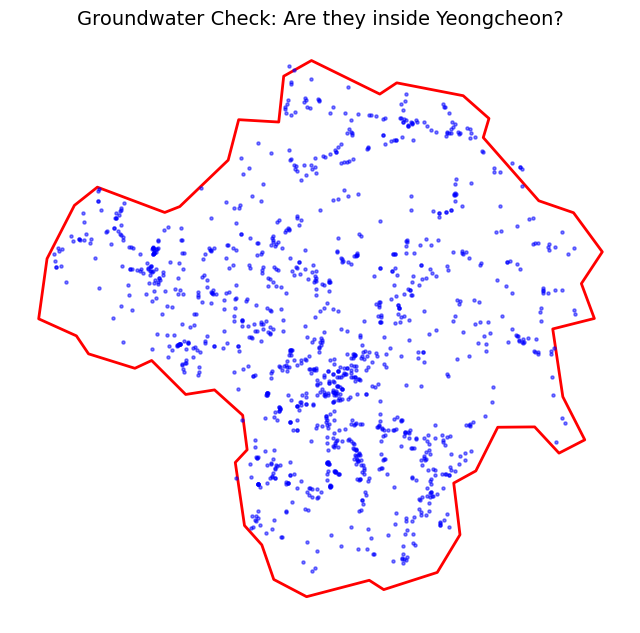

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

BASE_DIR = '/content/drive/MyDrive/영천의미학/'
WATER_PATH = BASE_DIR + '영천시_지하수_생활용_좌표완료.csv'

print("🔍 변환된 지하수 좌표 1,242개가 정상인지 검수합니다...")

# 1. 영천시 경계선만 빠르게 가져오기
url = "https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2013/json/skorea_municipalities_geo_simple.json"
korea_sig = gpd.read_file(url)
yeongcheon_border = korea_sig[korea_sig['name'] == '영천시'].to_crs(epsg=5179)

# 2. 지하수 데이터 불러와서 공간 데이터(점)로 만들기
df_water = pd.read_csv(WATER_PATH)
df_water_clean = df_water.dropna(subset=['위도', '경도'])

gdf_water = gpd.GeoDataFrame(
    df_water_clean,
    geometry=gpd.points_from_xy(df_water_clean['경도'], df_water_clean['위도']),
    crs="EPSG:4326"
).to_crs(epsg=5179) # 5179로 통일

# 3. 눈으로 확인하기 (시각화)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# 영천시 테두리 그리기
yeongcheon_border.plot(ax=ax, color='white', edgecolor='red', linewidth=2)

# 지하수 점 찍기 (파란색)
gdf_water.plot(ax=ax, color='blue', markersize=5, alpha=0.5)

plt.title("Groundwater Check: Are they inside Yeongcheon?", fontsize=14)
plt.axis('off')
plt.show()

In [2]:

!apt-get install -y fonts-nanum*
!rm -rf /root/.cache/matplotlib/* # 폰트 캐시 재설정

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# Nanum 글꼴 설치
!apt-get -y install fonts-nanum

# matplotlib에서 한글 폰트 사용 설정
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 나눔 글꼴 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
rc('font', family='NanumGothic')

import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum

fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) # 폰트 설정

import matplotlib.pyplot as plt
from matplotlib import font_manager

# 글꼴 경로 추가
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)

# 한글을 사용할 수 있도록 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
fonts-nanum is already the newest version (20200506-1).
The following NEW packages will be installed:
  fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 3 newly installed, 0 to remove and 3 not upgraded.
Need to get 35.7 MB of archives.
After this operation, 143 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0 MB]
Fetched 35.7 MB in 1s (42.7 MB/s)
Selecting previ

🗺️ [1/3] 1km 격자와 영천시 경계선을 불러옵니다...
📊 [2/3] 전처리된 고령인구 데이터를 지도에 결합합니다...
✨ [3/3] 고령인구 지도를 출력합니다!


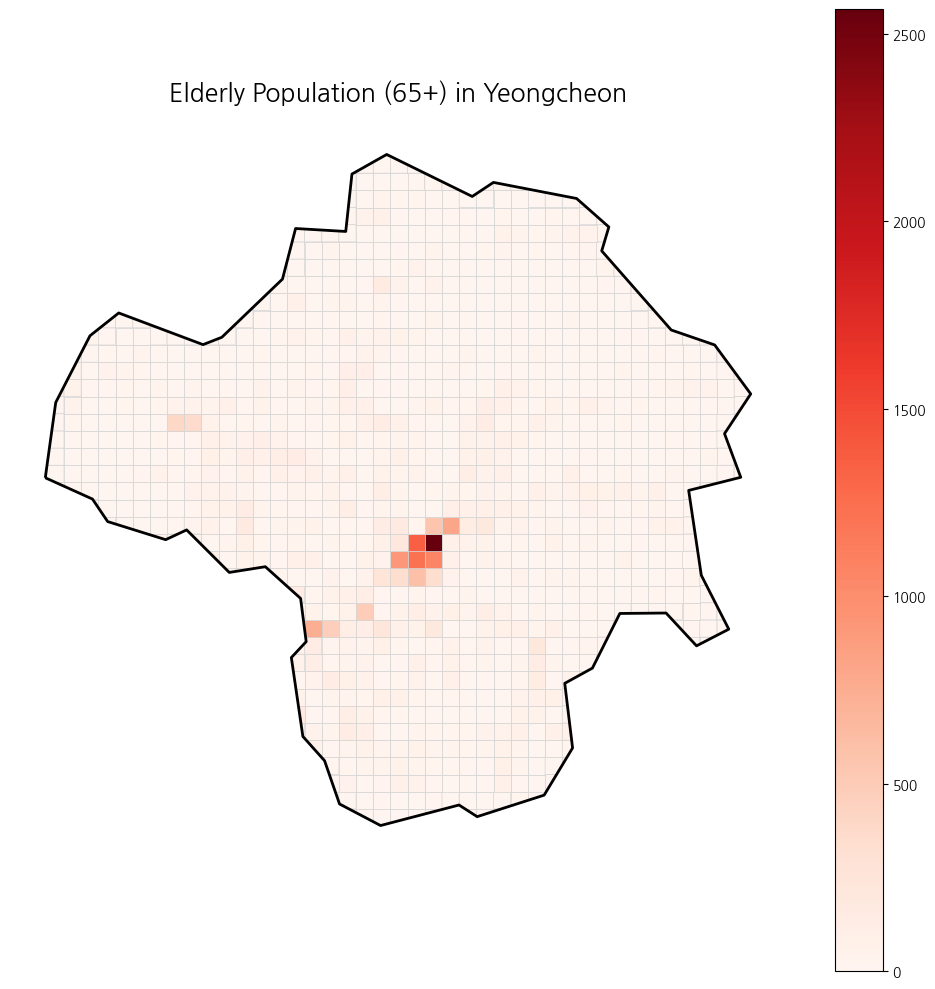

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ==============================================================
# 🚨 [세팅값] 경로
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 네가 수정한 경로 완벽 적용 완료!
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
POP_PRE_PATH = BASE_DIR + '2024년_인구_마마_1K_고령전처리.csv'

# ==============================================================
# 1. 도화지 세팅 (🔥 범인 검거: euc-kr 대신 utf-8 적용)
# ==============================================================
print("🗺️ [1/3] 1km 격자와 영천시 경계선을 불러옵니다...")

try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

# 영천시 경계선
url = "https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2013/json/skorea_municipalities_geo_simple.json"
korea_sig = gpd.read_file(url)
yeongcheon_border = korea_sig[korea_sig['name'] == '영천시'].to_crs(epsg=5179)

# 영천시 모양으로 자르기
yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)

# 격자코드 컬럼 찾아서 공백 제거
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()


# ==============================================================
# 2. 고령 인구 결합 (완벽한 CSV 파일 사용)
# ==============================================================
print("📊 [2/3] 전처리된 고령인구 데이터를 지도에 결합합니다...")
df_pop = pd.read_csv(POP_PRE_PATH)

pop_grid_col = df_pop.columns[0] # '격자코드'
df_pop[pop_grid_col] = df_pop[pop_grid_col].astype(str).str.strip()

# 지도(yeongcheon_grid)와 인구(df_pop) 병합
pop_map = yeongcheon_grid.merge(df_pop, left_on=grid_col, right_on=pop_grid_col, how='left')
pop_map['고령인구_합계'] = pop_map['고령인구_합계'].fillna(0)


# ==============================================================
# 3. 시각화
# ==============================================================
print("✨ [3/3] 고령인구 지도를 출력합니다!")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 0명이 아닌 곳들이 진한 빨간색으로 나와야 정상입니다!
pop_map.plot(column='고령인구_합계', ax=ax, cmap='Reds', edgecolor='lightgray', linewidth=0.5, legend=True)
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2)

ax.set_title('Elderly Population (65+) in Yeongcheon', fontsize=18, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

🗺️ [1/3] 1km 격자와 영천시 경계선을 불러옵니다...
📊 [2/3] 1인가구 데이터를 필터링하고 지도에 결합합니다...
✨ [3/3] 1인 가구 지도를 출력합니다!


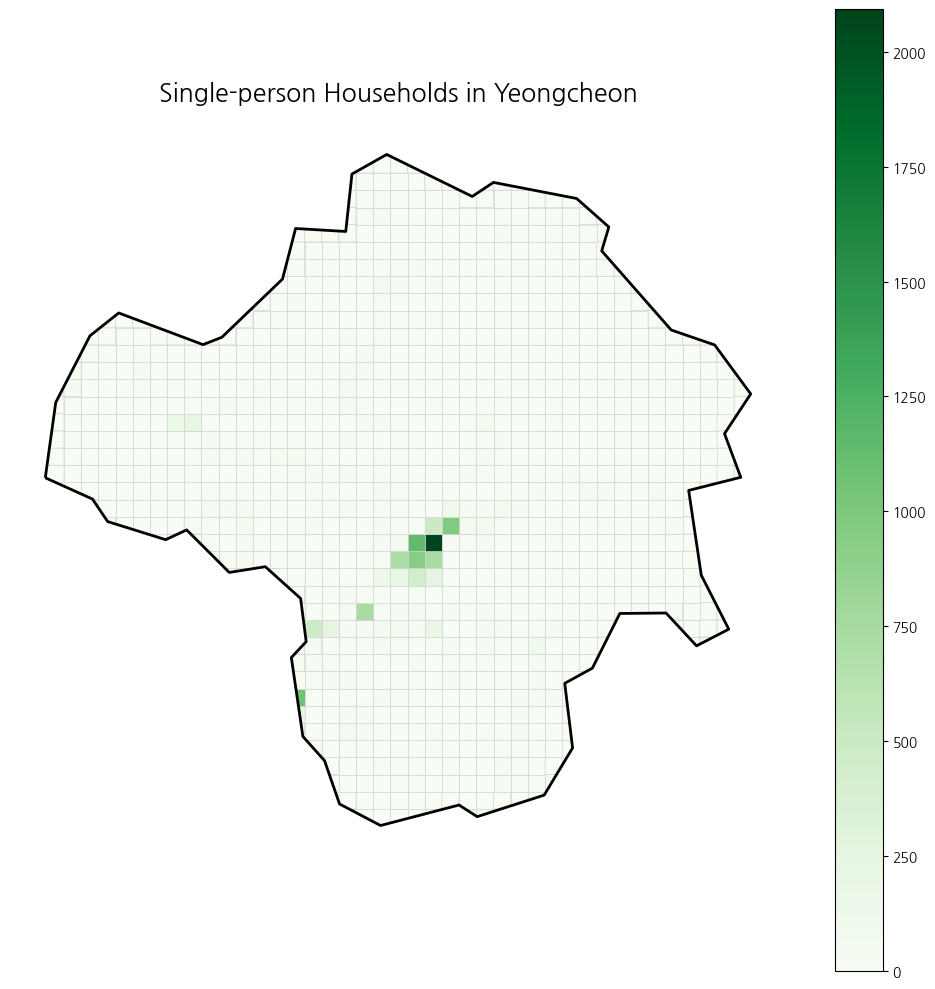

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ==============================================================
# 🚨 [세팅값] 경로
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
FAM_PATH = BASE_DIR + '2024년_가구_마마_1K.csv'

# ==============================================================
# 1. 도화지 세팅 (영천시 오려내기 & 외계어/공백 버그 방지)
# ==============================================================
print("🗺️ [1/3] 1km 격자와 영천시 경계선을 불러옵니다...")
try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

url = "https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2013/json/skorea_municipalities_geo_simple.json"
korea_sig = gpd.read_file(url)
yeongcheon_border = korea_sig[korea_sig['name'] == '영천시'].to_crs(epsg=5179)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()

# ==============================================================
# 2. 1인 가구(ga_sd_005) 데이터 결합
# ==============================================================
print("📊 [2/3] 1인가구 데이터를 필터링하고 지도에 결합합니다...")
try:
    df_fam_raw = pd.read_csv(FAM_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='utf-8')
except:
    df_fam_raw = pd.read_csv(FAM_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='cp949')

# 1인가구(ga_sd_005)만 추출 및 공백 제거
df_single = df_fam_raw[df_fam_raw['code'] == 'ga_sd_005'].copy()
df_single['grid_id'] = df_single['grid_id'].astype(str).str.strip()

# 지도와 병합
single_map = yeongcheon_grid.merge(df_single, left_on=grid_col, right_on='grid_id', how='left')
single_map['count'] = single_map['count'].fillna(0)

# ==============================================================
# 3. 시각화 (초록색 히트맵)
# ==============================================================
print("✨ [3/3] 1인 가구 지도를 출력합니다!")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

single_map.plot(column='count', ax=ax, cmap='Greens', edgecolor='lightgray', linewidth=0.5, legend=True)
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2)

ax.set_title('Single-person Households in Yeongcheon', fontsize=18, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

🗺️ [1/3] 1km 격자와 영천시 경계선을 불러옵니다...
💧 [2/3] 지하수 좌표를 지도에 얹고 개수를 셉니다...
✨ [3/3] 지하수 지도를 출력합니다!


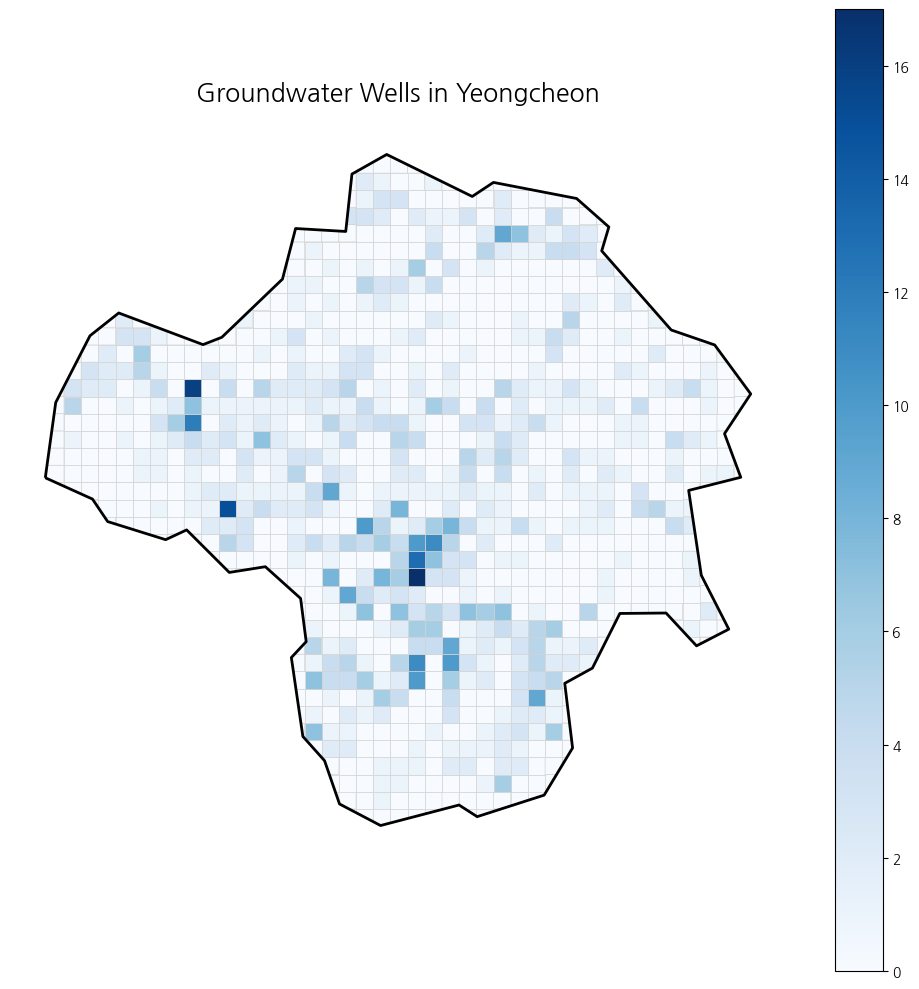

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ==============================================================
# 🚨 [세팅값] 경로
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
WATER_PATH = BASE_DIR + '영천시_지하수_생활용_좌표완료.csv'

# ==============================================================
# 1. 도화지 세팅
# ==============================================================
print("🗺️ [1/3] 1km 격자와 영천시 경계선을 불러옵니다...")
try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

url = "https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2013/json/skorea_municipalities_geo_simple.json"
korea_sig = gpd.read_file(url)
yeongcheon_border = korea_sig[korea_sig['name'] == '영천시'].to_crs(epsg=5179)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()

# ==============================================================
# 2. 지하수 좌표 공간 결합 (점 개수 카운트)
# ==============================================================
print("💧 [2/3] 지하수 좌표를 지도에 얹고 개수를 셉니다...")
df_water = pd.read_csv(WATER_PATH).dropna(subset=['위도', '경도'])

# 위경도 점(Point) 데이터 생성 및 5179 미터법으로 변환
gdf_water = gpd.GeoDataFrame(
    df_water, geometry=gpd.points_from_xy(df_water['경도'], df_water['위도']), crs="EPSG:4326"
).to_crs(epsg=5179)

# 영천시 격자 안에 들어오는 점만 추출 (sjoin)
joined_water = gpd.sjoin(gdf_water, yeongcheon_grid, how='inner', predicate='within')

# 격자코드(GRID_CD)별로 몇 개의 점이 있는지 카운트
water_counts = joined_water.groupby(grid_col).size().reset_index(name='water_wells')

# 카운트 결과를 원본 격자 지도에 병합
water_map = yeongcheon_grid.merge(water_counts, on=grid_col, how='left')
water_map['water_wells'] = water_map['water_wells'].fillna(0)

# ==============================================================
# 3. 시각화 (파란색 히트맵)
# ==============================================================
print("✨ [3/3] 지하수 지도를 출력합니다!")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

water_map.plot(column='water_wells', ax=ax, cmap='Blues', edgecolor='lightgray', linewidth=0.5, legend=True)
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2)

ax.set_title('Groundwater Wells in Yeongcheon', fontsize=18, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

🔄 [1/4] 도화지 및 모든 데이터를 불러와 하나로 합칩니다...
📊 [2/4] 소외 지역 식별을 위한 데이터 정규화 및 핫스팟 지수를 계산합니다...
✨ [3/4] 4분할 종합 대시보드를 렌더링합니다...


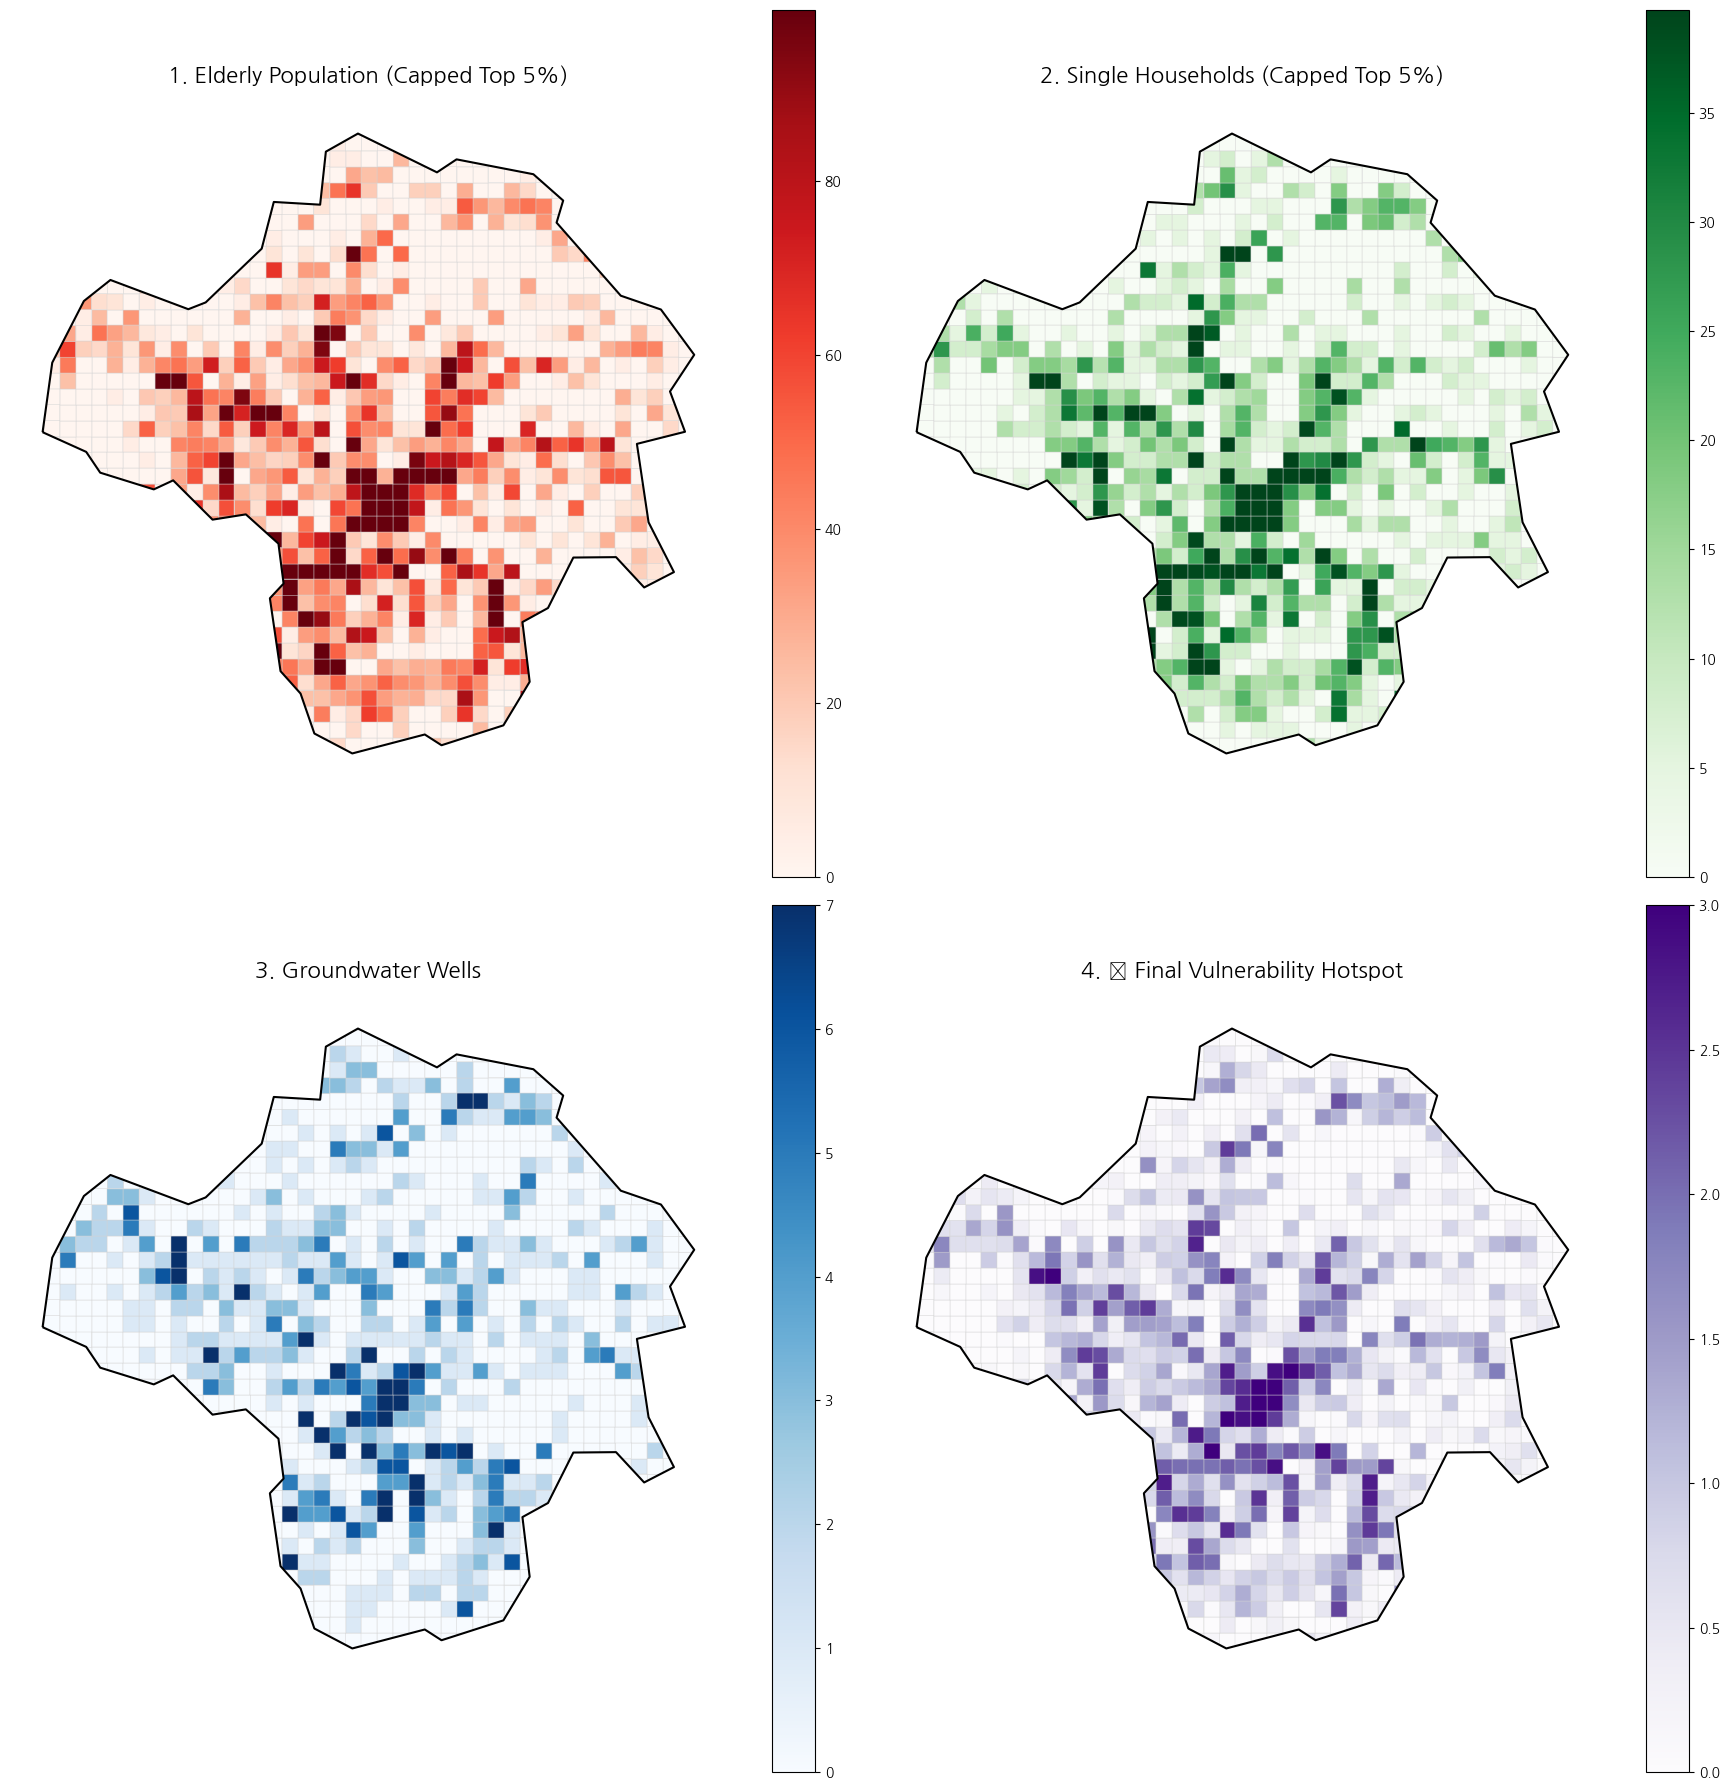

💾 [4/4] 최종 통합 데이터를 저장합니다...
✅ 완료! 구글 드라이브에 '영천시_B팀_최종결과' 파일이 생성되었습니다.


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings

# 경고창 무시
warnings.filterwarnings('ignore')

# ==============================================================
# 🚨 [세팅값] 데이터 경로
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
POP_PRE_PATH = BASE_DIR + '2024년_인구_마마_1K_고령전처리.csv'
FAM_PATH = BASE_DIR + '2024년_가구_마마_1K.csv'
WATER_PATH = BASE_DIR + '영천시_지하수_생활용_좌표완료.csv'

print("🔄 [1/4] 도화지 및 모든 데이터를 불러와 하나로 합칩니다...")

# 1. 도화지 세팅 (영천시 오려내기)
try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

url = "https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2013/json/skorea_municipalities_geo_simple.json"
korea_sig = gpd.read_file(url)
yeongcheon_border = korea_sig[korea_sig['name'] == '영천시'].to_crs(epsg=5179)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()

# 2. 인구 및 가구 병합
df_pop = pd.read_csv(POP_PRE_PATH)
df_pop[df_pop.columns[0]] = df_pop[df_pop.columns[0]].astype(str).str.strip()

try:
    df_fam_raw = pd.read_csv(FAM_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='utf-8')
except:
    df_fam_raw = pd.read_csv(FAM_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='cp949')
df_single = df_fam_raw[df_fam_raw['code'] == 'ga_sd_005'].copy()
df_single['grid_id'] = df_single['grid_id'].astype(str).str.strip()

final_map = yeongcheon_grid.merge(df_pop, left_on=grid_col, right_on=df_pop.columns[0], how='left')
final_map = final_map.merge(df_single, left_on=grid_col, right_on='grid_id', how='left')

# 3. 지하수 공간 병합
df_water = pd.read_csv(WATER_PATH).dropna(subset=['위도', '경도'])
gdf_water = gpd.GeoDataFrame(df_water, geometry=gpd.points_from_xy(df_water['경도'], df_water['위도']), crs="EPSG:4326").to_crs(epsg=5179)
joined_water = gpd.sjoin(gdf_water, yeongcheon_grid, how='inner', predicate='within')
water_counts = joined_water.groupby(grid_col).size().reset_index(name='water_wells')
final_map = final_map.merge(water_counts, on=grid_col, how='left')

# 결측치 0 처리
final_map['고령인구_합계'] = final_map['고령인구_합계'].fillna(0)
final_map['count'] = final_map['count'].fillna(0)  # 1인가구
final_map['water_wells'] = final_map['water_wells'].fillna(0)


print("📊 [2/4] 소외 지역 식별을 위한 데이터 정규화 및 핫스팟 지수를 계산합니다...")
# ==============================================================
# 🌟 [핵심] 이상치 Capping: 상위 5%의 압도적 수치를 잘라내어 시각적 대비 극대화
# ==============================================================
# 상위 5%에 해당하는 값을 상한선(vmax)으로 설정
pop_vmax = max(final_map['고령인구_합계'].quantile(0.95), 10)
single_vmax = max(final_map['count'].quantile(0.95), 10)
water_vmax = max(final_map['water_wells'].quantile(0.98), 5) # 지하수는 상위 2% 캡핑

# 취약도 계산을 위해 스케일링 전 상한선으로 자른 데이터 생성
final_map['pop_clipped'] = final_map['고령인구_합계'].clip(upper=pop_vmax)
final_map['single_clipped'] = final_map['count'].clip(upper=single_vmax)
final_map['water_clipped'] = final_map['water_wells'].clip(upper=water_vmax)

# 0~1 사이로 정규화 (MinMaxScaler)
scaler = MinMaxScaler()
final_map[['pop_scaled', 'single_scaled', 'water_scaled']] = scaler.fit_transform(final_map[['pop_clipped', 'single_clipped', 'water_clipped']])

# 3개 지표를 합산하여 '종합 취약 지수' 도출
final_map['Vulnerability_Index'] = final_map['pop_scaled'] + final_map['single_scaled'] + final_map['water_scaled']


print("✨ [3/4] 4분할 종합 대시보드를 렌더링합니다...")
# ==============================================================
# 시각화 (2x2 대시보드)
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

def plot_map(ax, column, cmap, title, vmax_val=None):
    # vmax를 적용하여 상위 값이 아닌 중간 값들의 색상 대비를 높임
    final_map.plot(column=column, ax=ax, cmap=cmap, vmax=vmax_val, edgecolor='lightgray', linewidth=0.3, legend=True)
    yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')

# 1. 고령인구 지도 (vmax 적용)
plot_map(axes[0, 0], '고령인구_합계', 'Reds', '1. Elderly Population (Capped Top 5%)', vmax_val=pop_vmax)

# 2. 1인가구 지도 (vmax 적용)
plot_map(axes[0, 1], 'count', 'Greens', '2. Single Households (Capped Top 5%)', vmax_val=single_vmax)

# 3. 지하수 관정 지도
plot_map(axes[1, 0], 'water_wells', 'Blues', '3. Groundwater Wells', vmax_val=water_vmax)

# 4. 🔥 종합 취약 핫스팟 지도
plot_map(axes[1, 1], 'Vulnerability_Index', 'Purples', '4. 🚨 Final Vulnerability Hotspot')

plt.tight_layout()
plt.show()

print("💾 [4/4] 최종 통합 데이터를 저장합니다...")
# 불필요한 계산용 컬럼 제거 후 팀 공유용으로 저장
save_df = final_map.drop(columns=['pop_clipped', 'single_clipped', 'water_clipped', 'pop_scaled', 'single_scaled', 'water_scaled'])
save_df.drop(columns='geometry').to_csv(BASE_DIR + '영천시_B팀_최종결과.csv', index=False, encoding='utf-8-sig')
save_df.to_file(BASE_DIR + "영천시_B팀_최종결과.geojson", driver='GeoJSON')
print(f"✅ 완료! 구글 드라이브에 '영천시_B팀_최종결과' 파일이 생성되었습니다.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🗺️ SGIS 정밀 시군구 경계 데이터를 불러옵니다...
✅ [utf-8] 인코딩으로 글자 깨짐 없이 완벽하게 불러왔습니다!

[데이터 내부 확인]


,SIGUNGU_CD,SIGUNGU_NM
0,37070,영천시



✅ 영천시 경계 추출 완료! (총 1개 구역)


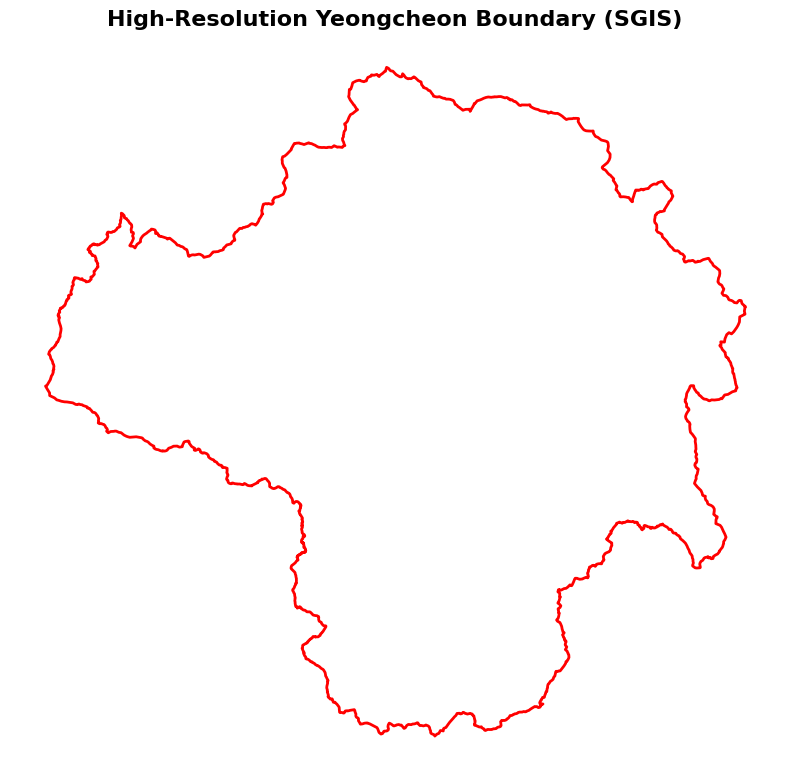

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
from google.colab import drive

warnings.filterwarnings('ignore')

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# SGIS 파일 경로
BORDER_PATH = '/content/drive/MyDrive/영천의미학/시군구/bnd_sigungu_37070_2025_2Q.shp'

print("🗺️ SGIS 정밀 시군구 경계 데이터를 불러옵니다...")

# 1. 인코딩 3대장 다 찔러보기 (utf-8부터 먼저!)
encodings = ['utf-8', 'euc-kr', 'cp949']
sigungu_map = None

for enc in encodings:
    try:
        temp_map = gpd.read_file(BORDER_PATH, encoding=enc)
        # 글자가 안 깨지는지 확인
        if '영천' in str(temp_map['SIGUNGU_NM'].iloc[0]):
            sigungu_map = temp_map
            print(f"✅ [{enc}] 인코딩으로 글자 깨짐 없이 완벽하게 불러왔습니다!")
            break
    except:
        continue

# 만약 다 실패했어도 일단 기본으로 불러오기
if sigungu_map is None:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')

sigungu_map = sigungu_map.to_crs(epsg=5179)

# 데이터 내부 확인 (글자가 제대로 들어왔는지 눈으로 체크)
print("\n[데이터 내부 확인]")
display(sigungu_map[['SIGUNGU_CD', 'SIGUNGU_NM']].head())


# 2. 영천시 필터링 (안전 장치 추가)
sigungu_map['SIGUNGU_NM'] = sigungu_map['SIGUNGU_NM'].astype(str).str.strip()
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'] == '영천시'].copy()

# ⭐️ 만약 필터링했더니 0개다? = 파일 자체가 이미 영천시 데이터라는 뜻!
if len(yeongcheon_border) == 0:
    print("\n👉 필터링 결과가 0개입니다. 다운받으신 파일이 이미 '영천시' 단일 데이터이므로 원본을 그대로 그립니다!")
    yeongcheon_border = sigungu_map.copy()
else:
    print(f"\n✅ 영천시 경계 추출 완료! (총 {len(yeongcheon_border)}개 구역)")


# 3. 눈으로 확인하기 (시각화)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# 배경은 투명(white)하게, 테두리는 빨간색으로 그리기
yeongcheon_border.plot(ax=ax, color='white', edgecolor='red', linewidth=2)

# 폰트 에러 방지용 영문 타이틀
ax.set_title('High-Resolution Yeongcheon Boundary (SGIS)', fontsize=16, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

🔄 [1/4] SGIS 정밀 경계선 및 도화지 세팅 중...
📊 [2/4] 인구, 가구, 지하수 데이터를 격자에 결합합니다...
🔥 [3/4] 롱테일 대비 강화 및 종합 취약도 점수를 계산합니다...
✨ [4/4] 4분할 종합 대시보드 출력 및 최종 파일 저장 중...


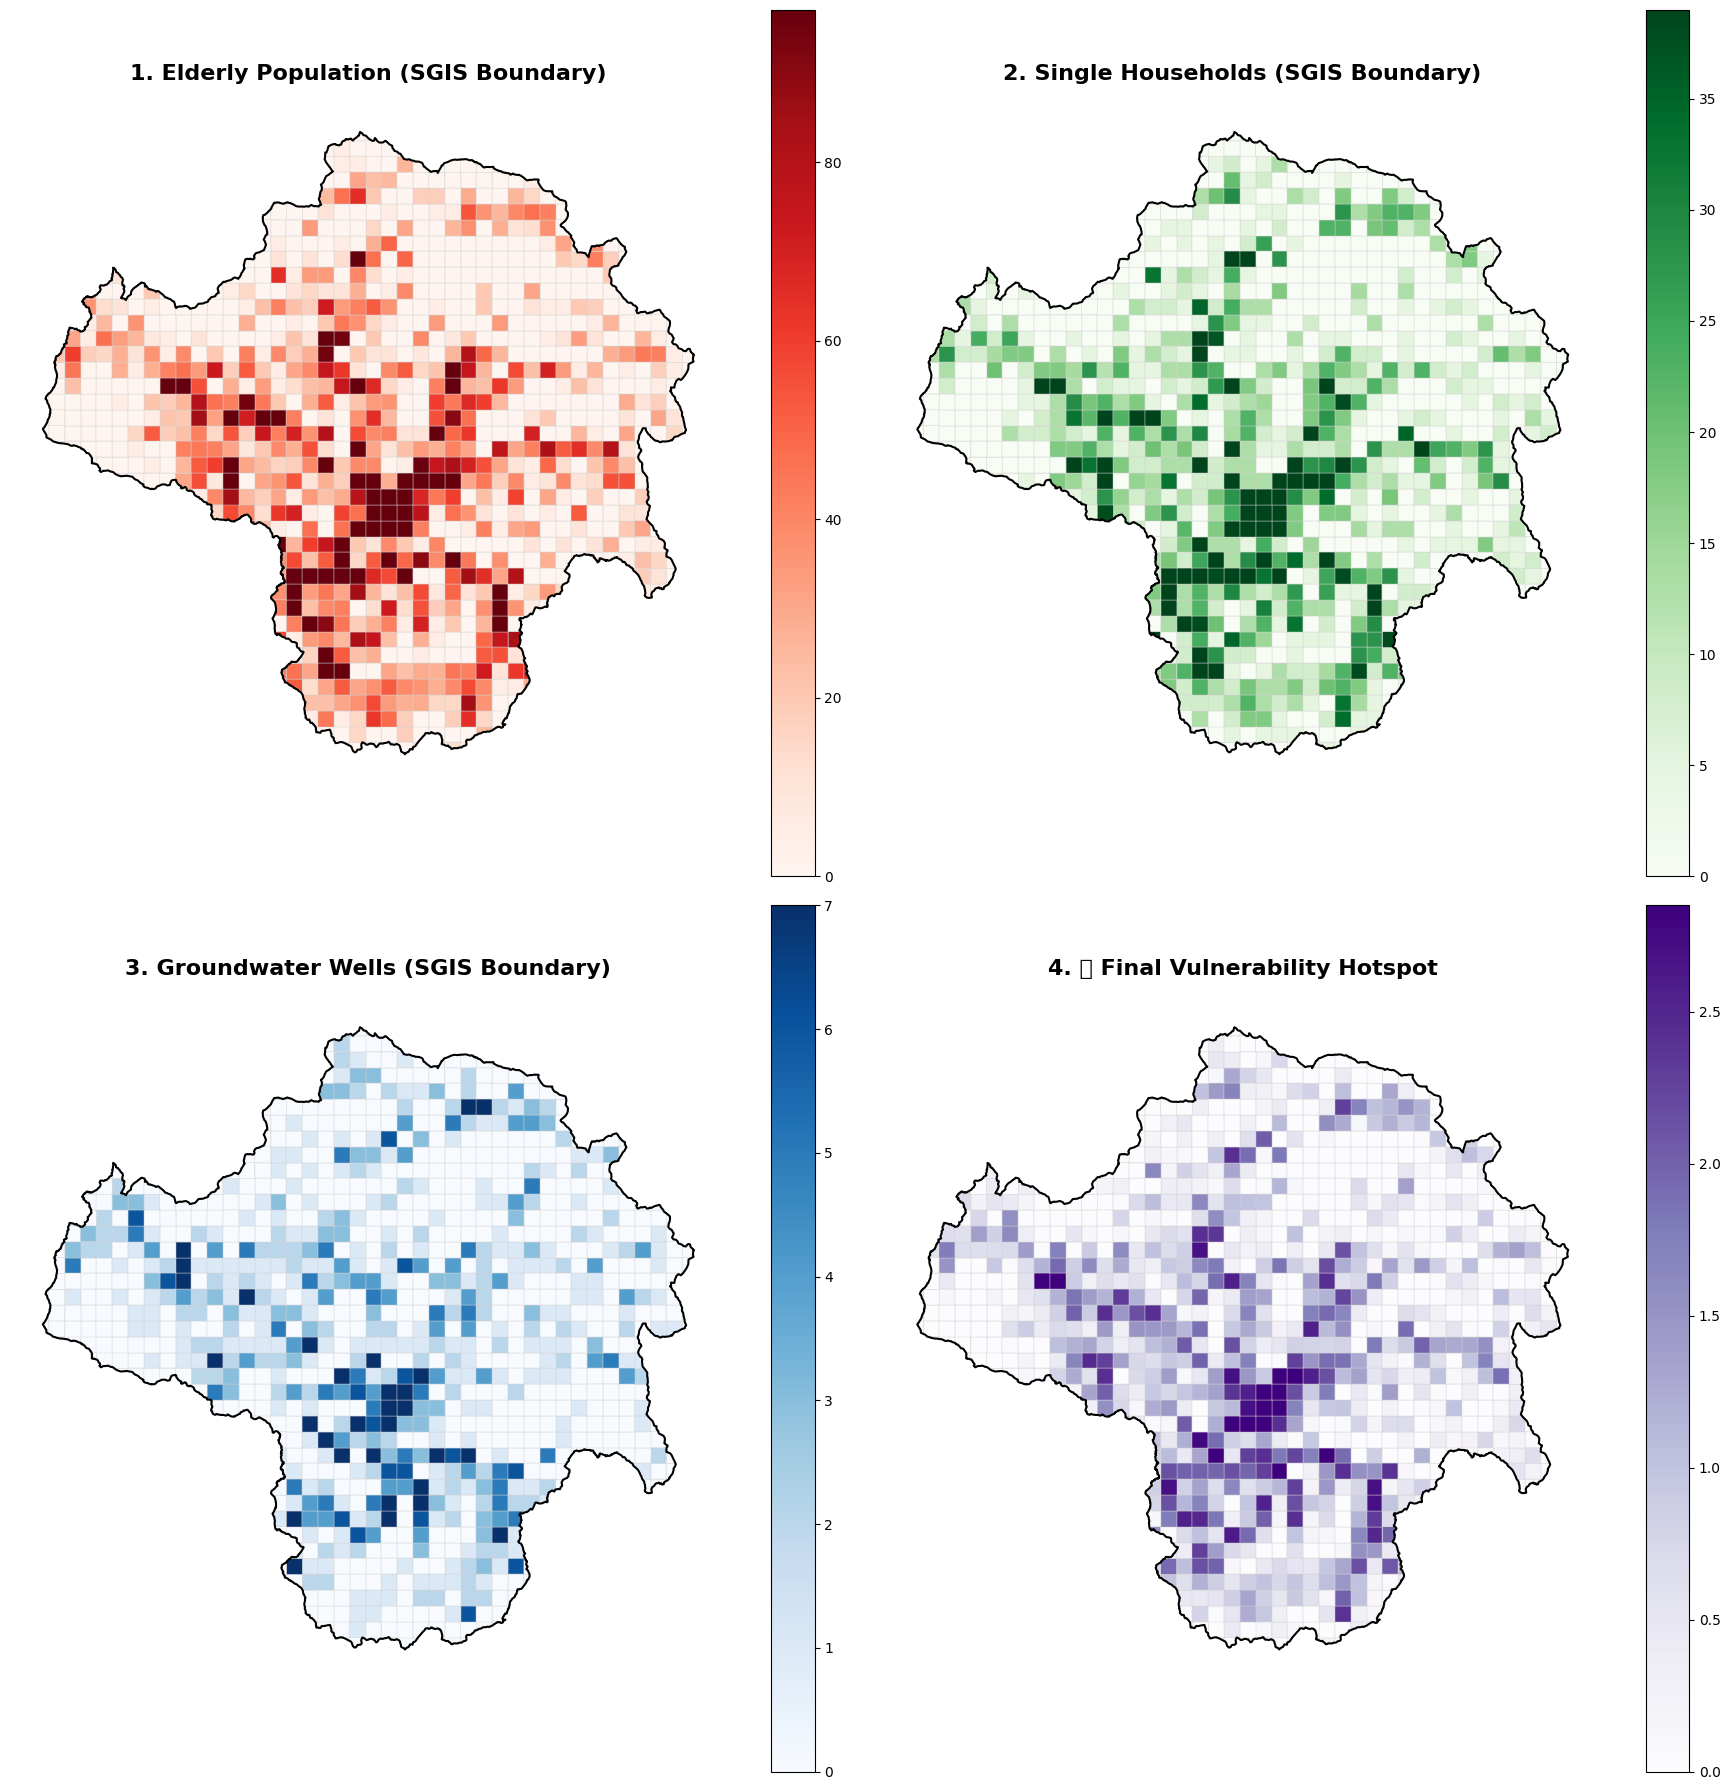

✅ 완벽하게 종료되었습니다! 공유용 파일이 생성되었습니다: /content/drive/MyDrive/영천의미학/영천시_B팀_찐최종.csv


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings

# 경고창 무시
warnings.filterwarnings('ignore')

# ==============================================================
# 🚨 [세팅값] 데이터 경로 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 1km 격자 및 SGIS 정밀 경계선 경로
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'

# 속성 및 공간 데이터 경로
POP_PRE_PATH = BASE_DIR + '2024년_인구_마마_1K_고령전처리.csv'
FAM_PATH = BASE_DIR + '2024년_가구_마마_1K.csv'
WATER_PATH = BASE_DIR + '영천시_지하수_생활용_좌표완료.csv'

# ==============================================================
print("🔄 [1/4] SGIS 정밀 경계선 및 도화지 세팅 중...")
# ==============================================================
# 1. SGIS 정밀 경계선 불러오기 (인코딩 자동 방어)
encodings = ['utf-8', 'euc-kr', 'cp949']
sigungu_map = None

for enc in encodings:
    try:
        temp_map = gpd.read_file(BORDER_PATH, encoding=enc)
        if 'SIGUNGU_NM' in temp_map.columns and '영천' in str(temp_map['SIGUNGU_NM'].iloc[0]):
            sigungu_map = temp_map
            break
    except:
        continue
if sigungu_map is None:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')

sigungu_map = sigungu_map.to_crs(epsg=5179)
sigungu_map['SIGUNGU_NM'] = sigungu_map['SIGUNGU_NM'].astype(str).str.strip()
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'] == '영천시'].copy()

# 파일 자체가 영천시 단일 데이터인 경우 대비
if len(yeongcheon_border) == 0:
    yeongcheon_border = sigungu_map.copy()

# 2. 1km 격자판 불러오기 및 영천시 경계로 예쁘게 오려내기(Clip)
try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()


# ==============================================================
print("📊 [2/4] 인구, 가구, 지하수 데이터를 격자에 결합합니다...")
# ==============================================================
# 1. 고령인구 병합
df_pop = pd.read_csv(POP_PRE_PATH)
df_pop[df_pop.columns[0]] = df_pop[df_pop.columns[0]].astype(str).str.strip()

# 2. 1인가구 병합 (ga_sd_005)
try:
    df_fam_raw = pd.read_csv(FAM_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='utf-8')
except:
    df_fam_raw = pd.read_csv(FAM_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='cp949')
df_single = df_fam_raw[df_fam_raw['code'] == 'ga_sd_005'].copy()
df_single['grid_id'] = df_single['grid_id'].astype(str).str.strip()

final_map = yeongcheon_grid.merge(df_pop, left_on=grid_col, right_on=df_pop.columns[0], how='left')
final_map = final_map.merge(df_single, left_on=grid_col, right_on='grid_id', how='left')

# 3. 지하수 공간 병합 (sjoin)
df_water = pd.read_csv(WATER_PATH).dropna(subset=['위도', '경도'])
gdf_water = gpd.GeoDataFrame(df_water, geometry=gpd.points_from_xy(df_water['경도'], df_water['위도']), crs="EPSG:4326").to_crs(epsg=5179)

joined_water = gpd.sjoin(gdf_water, yeongcheon_grid, how='inner', predicate='within')
water_counts = joined_water.groupby(grid_col).size().reset_index(name='water_wells')
final_map = final_map.merge(water_counts, on=grid_col, how='left')

# 결측치 0 처리
final_map['고령인구_합계'] = final_map['고령인구_합계'].fillna(0)
final_map['count'] = final_map['count'].fillna(0)
final_map['water_wells'] = final_map['water_wells'].fillna(0)


# ==============================================================
print("🔥 [3/4] 롱테일 대비 강화 및 종합 취약도 점수를 계산합니다...")
# ==============================================================
# 1. 가중치 설정 (언제든 수정 가능!)
W_POP = 1.0
W_SINGLE = 1.0
W_WATER = 1.0

# 2. 상위 % Capping (색상 대비 강화)
pop_vmax = max(final_map['고령인구_합계'].quantile(0.95), 10)
single_vmax = max(final_map['count'].quantile(0.95), 10)
water_vmax = max(final_map['water_wells'].quantile(0.98), 5)

final_map['pop_clipped'] = final_map['고령인구_합계'].clip(upper=pop_vmax)
final_map['single_clipped'] = final_map['count'].clip(upper=single_vmax)
final_map['water_clipped'] = final_map['water_wells'].clip(upper=water_vmax)

# 3. 0~1 정규화 및 최종 스코어 계산
scaler = MinMaxScaler()
final_map[['pop_scaled', 'single_scaled', 'water_scaled']] = scaler.fit_transform(final_map[['pop_clipped', 'single_clipped', 'water_clipped']])
final_map['Vulnerability_Index'] = (final_map['pop_scaled'] * W_POP) + (final_map['single_scaled'] * W_SINGLE) + (final_map['water_scaled'] * W_WATER)


# ==============================================================
print("✨ [4/4] 4분할 종합 대시보드 출력 및 최종 파일 저장 중...")
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

def plot_map(ax, column, cmap, title, vmax_val=None):
    final_map.plot(column=column, ax=ax, cmap=cmap, vmax=vmax_val, edgecolor='lightgray', linewidth=0.3, legend=True)
    # 🌟 새롭게 추가된 엣지있는 정밀 경계선!
    yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')

plot_map(axes[0, 0], '고령인구_합계', 'Reds', '1. Elderly Population (SGIS Boundary)', vmax_val=pop_vmax)
plot_map(axes[0, 1], 'count', 'Greens', '2. Single Households (SGIS Boundary)', vmax_val=single_vmax)
plot_map(axes[1, 0], 'water_wells', 'Blues', '3. Groundwater Wells (SGIS Boundary)', vmax_val=water_vmax)
plot_map(axes[1, 1], 'Vulnerability_Index', 'Purples', '4. 🚨 Final Vulnerability Hotspot', vmax_val=(W_POP+W_SINGLE+W_WATER)*0.95)

plt.tight_layout()
plt.show()

# 데이터 정리 및 추출
save_cols = ['GRID_CD', '고령인구_합계', 'count', 'water_wells', 'Vulnerability_Index', 'geometry']
# grid_col 이름이 GRID_CD가 아닐 수 있으므로 안전하게 변경
final_map.rename(columns={grid_col: 'GRID_CD'}, inplace=True)
save_df = final_map[save_cols].rename(columns={'count': '1인가구_합계'})

save_df.drop(columns='geometry').to_csv(BASE_DIR + '영천시_B팀_찐최종.csv', index=False, encoding='utf-8-sig')
save_df.to_file(BASE_DIR + "영천시_B팀_찐최종.geojson", driver='GeoJSON')
print(f"✅ 완벽하게 종료되었습니다! 공유용 파일이 생성되었습니다: {BASE_DIR}영천시_B팀_찐최종.csv")